In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra;
interpolate = pyimport("scipy.interpolate").interp1d

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


PyObject <class 'scipy.interpolate.interpolate.interp1d'>

In [3]:
dir = "wannier"
Hwannier, cell_map = hwannier("$dir/wannier"), np.loadtxt("$dir/wannier.map.txt")
Pwannier = pwannier("$dir/wannier");
Heph, celleph_map = hephwannier("$dir/wannier"), np.loadtxt("$dir/wannier.mapeph.txt");
force_matrix, cellph_map = phonon_force_matrix("$dir/totalE");
phonon_bands = phonon_dispersion(force_matrix, cellph_map, return_negative=true);
dirac_point = wannier_bands(Hwannier, cell_map, [2/3, -1/3, 0])[1][5]
lattice_vectors = loadlattice("$dir/wannier.out");
μ = dirac_point + 0.5;

In [29]:
es, cs = drude_conductivity(lattice_vectors, Hwannier, cell_map, Pwannier, mesh=20, 
    num_blocks=500, histogram_width=20, degeneracy=2)

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Block: 1

([-100.0, -99.94998749687421, -99.89997499374844, -99.84996249062266, -99.79994998749687, -99.74993748437109, -99.69992498124532, -99.64991247811953, -99.59989997499375, -99.54988747186796  …  99.54988747186796, 99.59989997499375, 99.64991247811953, 99.69992498124532, 99.74993748437109, 99.79994998749687, 99.84996249062266, 99.89997499374844, 99.94998749687421, 100.0], [0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0])

In [35]:
println("Drude conductivity at Fermi surface: $(smooth((cs[:, 1, 1]+cs[:, 2, 2]) ./ 2, win_len=5)[argmin(abs.(es .- μ))])")

Drude conductivity at Fermi surface: 0.6670006932642414


In [39]:
println("Conductivity predicted by analytic formula is $(2/pi)")

Conductivity predicted by analytic formula is 0.6366197723675814


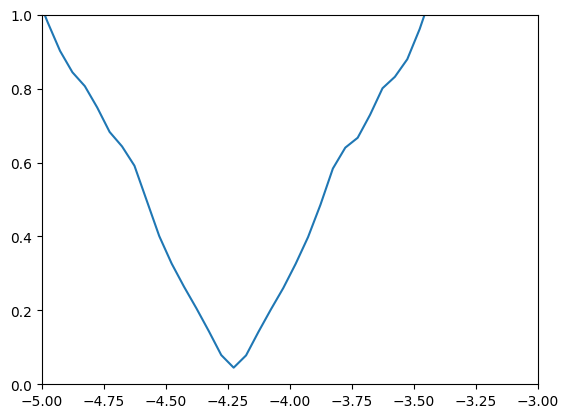

(0.0, 1.0)

In [34]:
plot(es, smooth(cs[:, 1, 1]+cs[:, 2, 2], win_len=5) ./ 2)
xlim(-5, -3)
ylim(0, 1)